# Old vs New Labels — Pathology Classification Comparison

## Objective
Compare pathology classification performance between old and new label definitions,
using CatBoost with raw features and LOSO cross-validation (k=30 calibration).

## Data
- **Source:** `results/tables/newlabels/patho_clf_results.csv`
- **Tags:** `oldlabels`, `newlabels`
- **Metrics:** AUC, MCC, Accuracy, F1, Precision, Recall

In [1]:
import os
from pathlib import Path

if Path.cwd().name != 'eeg-site-effects':
    os.chdir('../..')
print('Working directory:', Path.cwd())

Working directory: /dmj/fizmed/kchorzela/licencjat/eeg-site-effects


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy import stats

RESULTS_FILE = 'results/tables/newlabels/patho_clf_results.csv'
FIGURES_DIR  = 'results/figures/newlabels'
os.makedirs(FIGURES_DIR, exist_ok=True)

METRICS = ['auc', 'mcc', 'accuracy', 'f1-score', 'precision', 'recall']
LABEL_COLORS = {'oldlabels': '#1f77b4', 'newlabels': '#ff7f0e'}

def natural_sort_key(s):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', str(s))]

In [3]:
df = pd.read_csv(RESULTS_FILE)
print(f"Shape: {df.shape}")
print(f"Tags: {df['tag'].unique()}")
print(f"Hospitals: {df['hospital'].nunique()}")
print(f"Models: {df['model'].unique()}")
df.head()

Shape: (60, 12)
Tags: ['oldlabels' 'newlabels']
Hospitals: 30
Models: ['catboost']


,accuracy,precision,recall,f1-score,auc,mcc,hospital,model,method,n_calib,n_test,tag
0,0.699769,0.530364,0.903448,0.668367,0.870714,0.477339,H1,catboost,raw,30,433,oldlabels
1,0.674321,0.571286,0.805164,0.668355,0.795231,0.387068,H10,catboost,raw,30,10452,oldlabels
2,0.770718,0.789474,0.862832,0.824524,0.852518,0.499805,H11,catboost,raw,30,362,oldlabels
3,0.810400,0.928194,0.838740,0.881203,0.858490,0.431277,H12,catboost,raw,30,1250,oldlabels
4,0.742574,0.766917,0.829268,0.796875,0.832664,0.449533,H13,catboost,raw,30,202,oldlabels


## Summary Table — Mean Metrics by Label Type

In [4]:
summary = df.groupby('tag')[METRICS].agg(['mean', 'std']).round(4)
summary.columns = [f'{m}_{s}' for m, s in summary.columns]
print(summary.to_string())

# Difference (new - old)
old = df[df['tag'] == 'oldlabels'][METRICS].mean()
new = df[df['tag'] == 'newlabels'][METRICS].mean()
diff = new - old
print('\nDifference (new - old):')
print(diff.round(4).to_string())

           auc_mean  auc_std  mcc_mean  mcc_std  accuracy_mean  accuracy_std  f1-score_mean  f1-score_std  precision_mean  precision_std  recall_mean  recall_std
tag                                                                                                                                                              
newlabels    0.8051   0.0485    0.4206   0.1025         0.7171        0.1013         0.6212        0.0898          0.6814         0.1636       0.6196      0.1405
oldlabels    0.7985   0.0789    0.3935   0.1299         0.6906        0.0958         0.6940        0.1026          0.7162         0.1834       0.7303      0.1407

Difference (new - old):
auc          0.0066
mcc          0.0271
accuracy     0.0265
f1-score    -0.0728
precision   -0.0348
recall      -0.1108


## Statistical Test — Paired Wilcoxon per Metric

Each hospital is a paired observation (same hospital, different label definition).

In [5]:
hospitals = sorted(df['hospital'].unique(), key=natural_sort_key)
old_df = df[df['tag'] == 'oldlabels'].set_index('hospital').reindex(hospitals)
new_df = df[df['tag'] == 'newlabels'].set_index('hospital').reindex(hospitals)

stat_results = []
for metric in METRICS:
    old_vals = old_df[metric].values
    new_vals = new_df[metric].values
    wilcoxon_stat, wilcoxon_p = stats.wilcoxon(old_vals, new_vals)
    stat_results.append({
        'metric': metric,
        'old_mean': np.mean(old_vals),
        'new_mean': np.mean(new_vals),
        'diff_mean': np.mean(new_vals - old_vals),
        'wilcoxon_stat': wilcoxon_stat,
        'p_value': wilcoxon_p,
        'significant': wilcoxon_p < 0.05
    })

stat_df = pd.DataFrame(stat_results).round(4)
print(stat_df.to_string(index=False))

   metric  old_mean  new_mean  diff_mean  wilcoxon_stat  p_value  significant
      auc    0.7985    0.8051     0.0066          232.0   1.0000        False
      mcc    0.3935    0.4206     0.0271          164.0   0.1642        False
 accuracy    0.6906    0.7171     0.0265          141.0   0.0606        False
 f1-score    0.6940    0.6212    -0.0728           46.0   0.0000         True
precision    0.7162    0.6814    -0.0348          165.0   0.1706        False
   recall    0.7303    0.6196    -0.1108           10.0   0.0000         True


## Bar Chart — Mean Metrics (Old vs New)

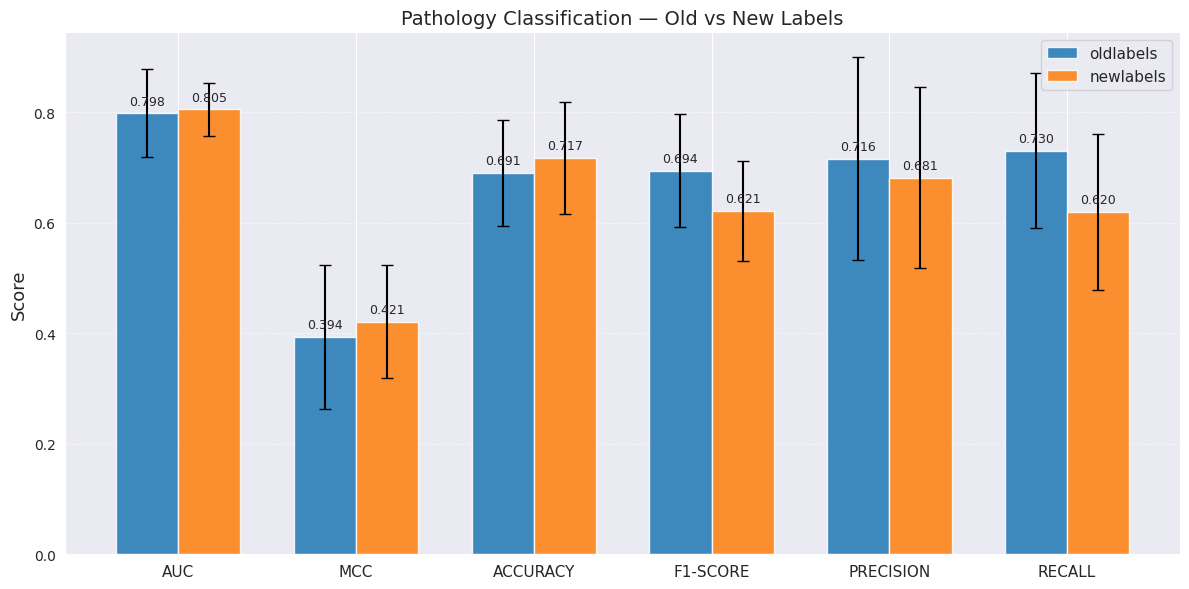

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(METRICS))
width = 0.35

for i, tag in enumerate(['oldlabels', 'newlabels']):
    tag_df = df[df['tag'] == tag]
    means = [tag_df[m].mean() for m in METRICS]
    stds = [tag_df[m].std() for m in METRICS]
    bars = ax.bar(x + i * width, means, width, yerr=stds, capsize=4,
                  label=tag, color=LABEL_COLORS[tag], alpha=0.85)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score', fontsize=13)
ax.set_title('Pathology Classification — Old vs New Labels', fontsize=14)
ax.set_xticks(x + width/2)
ax.set_xticklabels([m.upper() for m in METRICS], fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/old_vs_new_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-Hospital Comparison — AUC and MCC

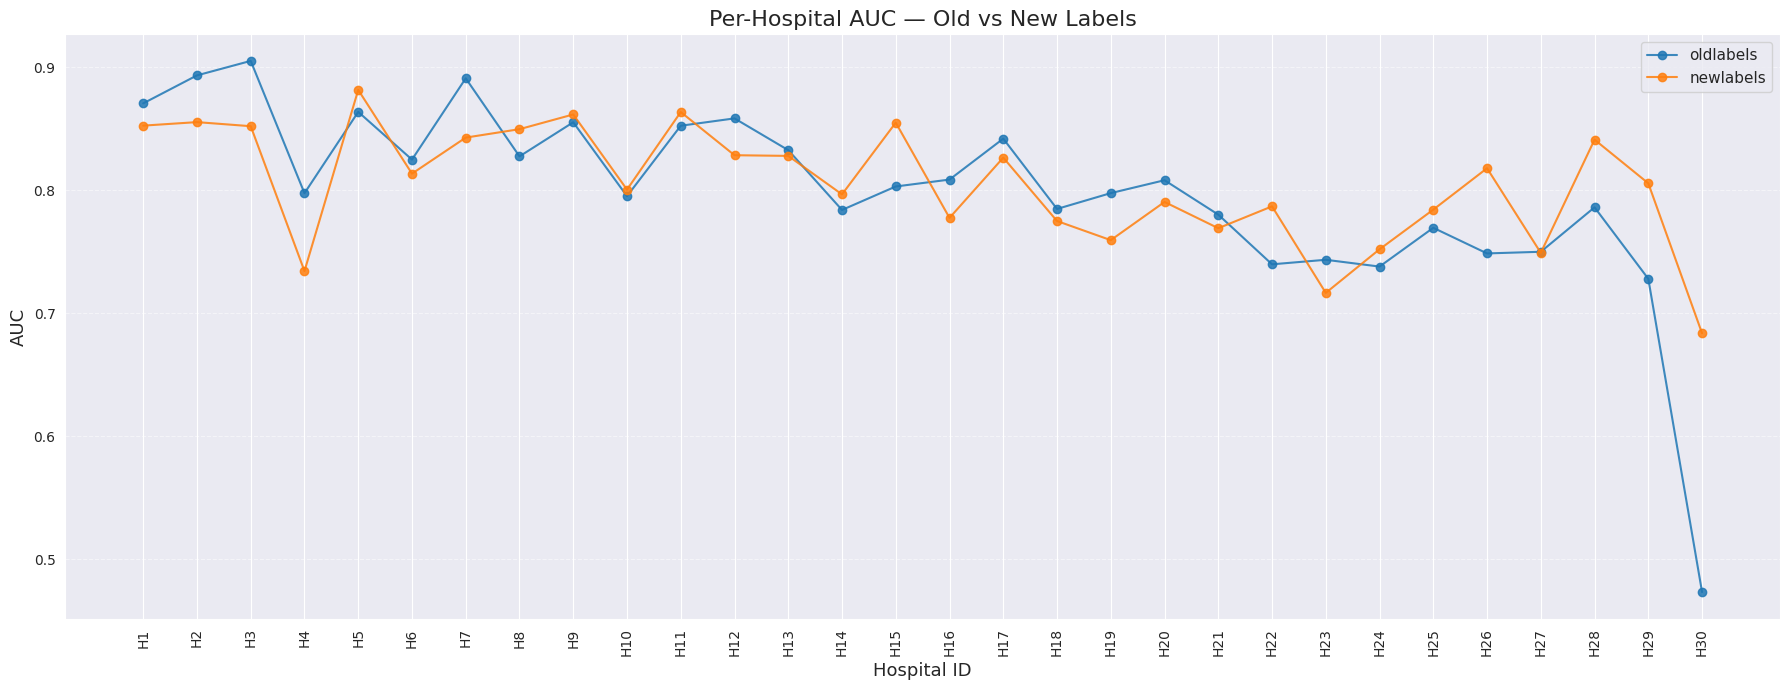

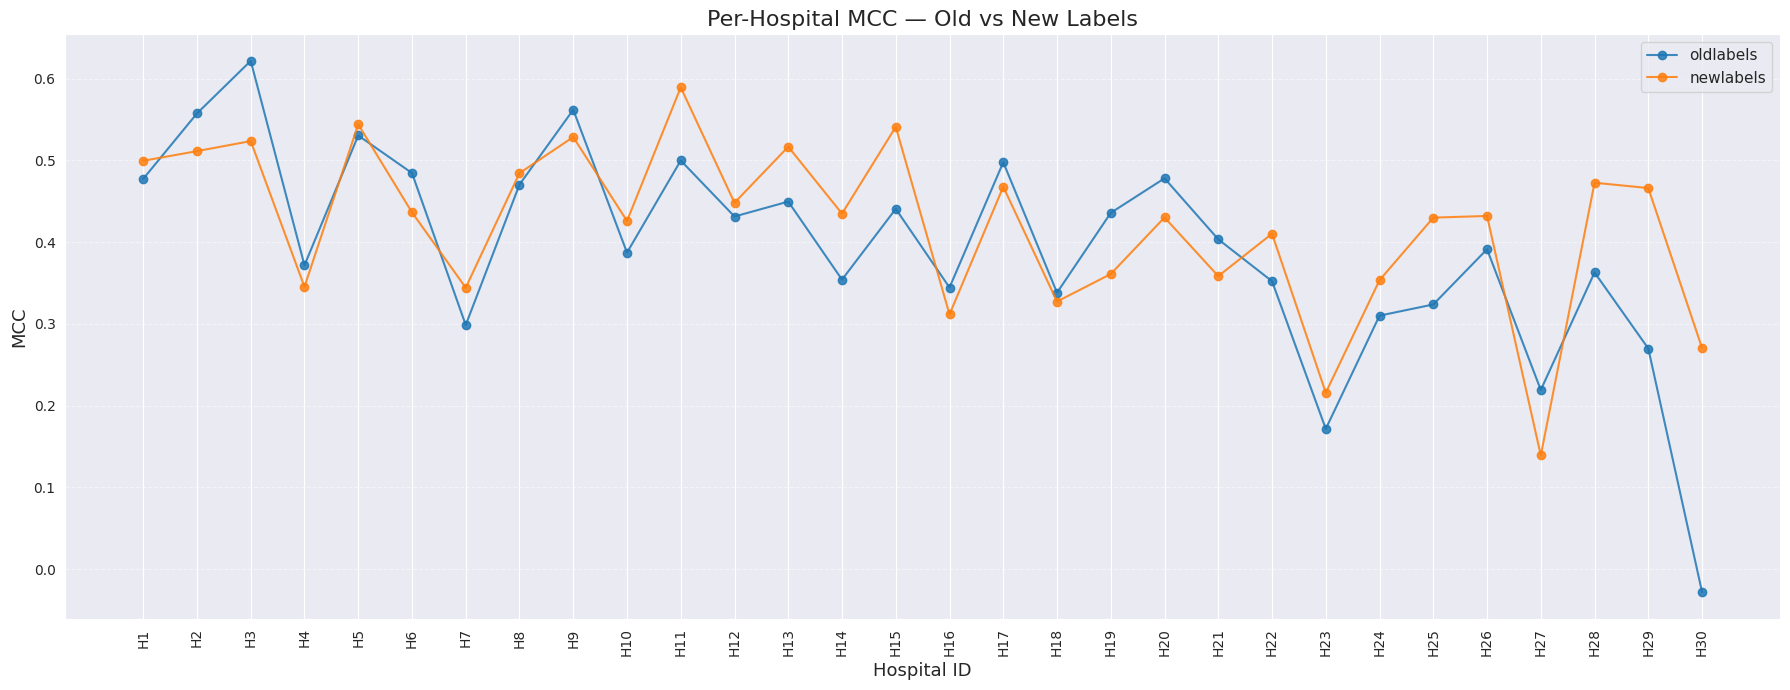

In [7]:
for metric in ['auc', 'mcc']:
    fig, ax = plt.subplots(figsize=(18, 7))

    for tag in ['oldlabels', 'newlabels']:
        tag_df = df[df['tag'] == tag].set_index('hospital').reindex(hospitals)
        ax.plot(hospitals, tag_df[metric].values, marker='o', linestyle='-',
                color=LABEL_COLORS[tag], label=tag, alpha=0.85)

    ax.set_title(f'Per-Hospital {metric.upper()} — Old vs New Labels', fontsize=16)
    ax.set_ylabel(metric.upper(), fontsize=13)
    ax.set_xlabel('Hospital ID', fontsize=13)
    ax.tick_params(axis='x', rotation=90)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.legend(fontsize=11)
    fig.tight_layout()
    fig.savefig(f'{FIGURES_DIR}/old_vs_new_{metric}_per_hospital.png', dpi=150, bbox_inches='tight')
    plt.show()

## Paired Difference Plot — Per Hospital (New - Old)

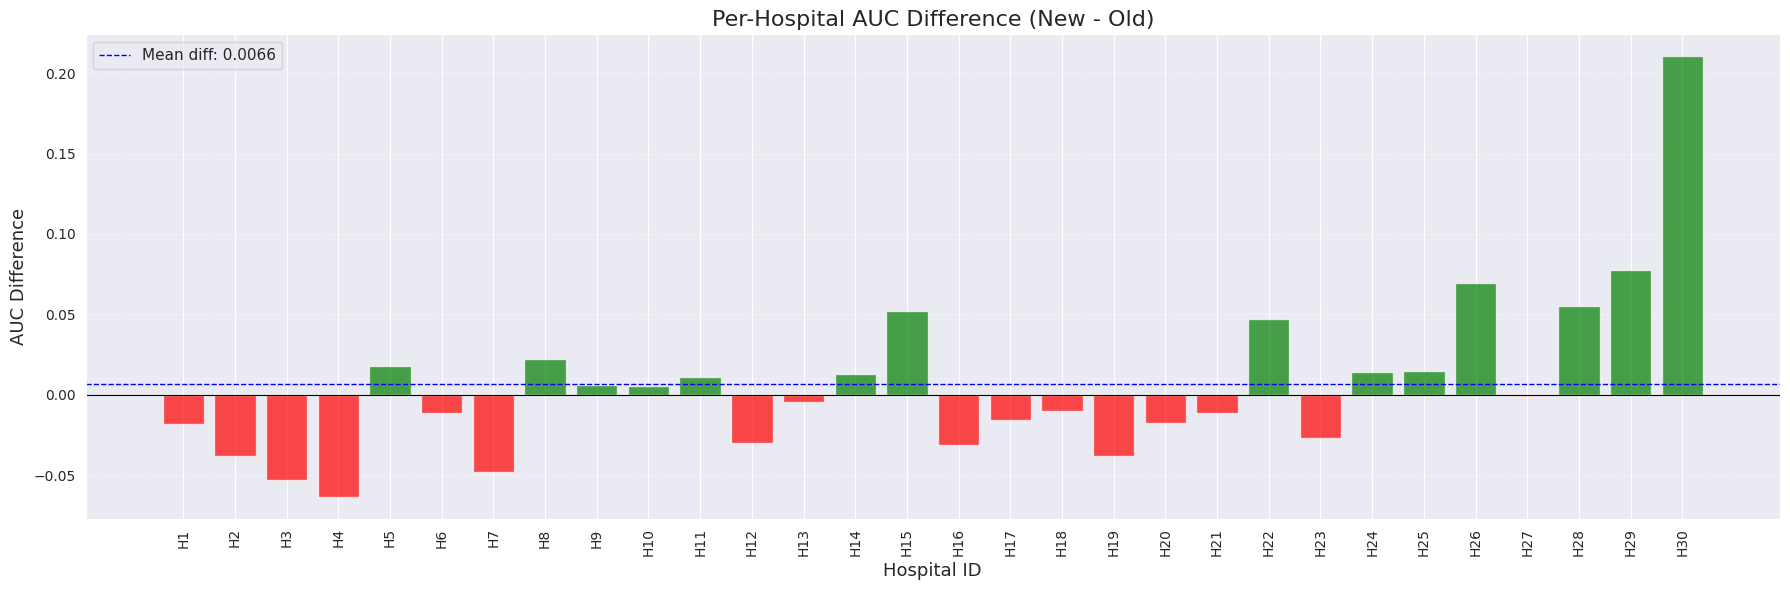

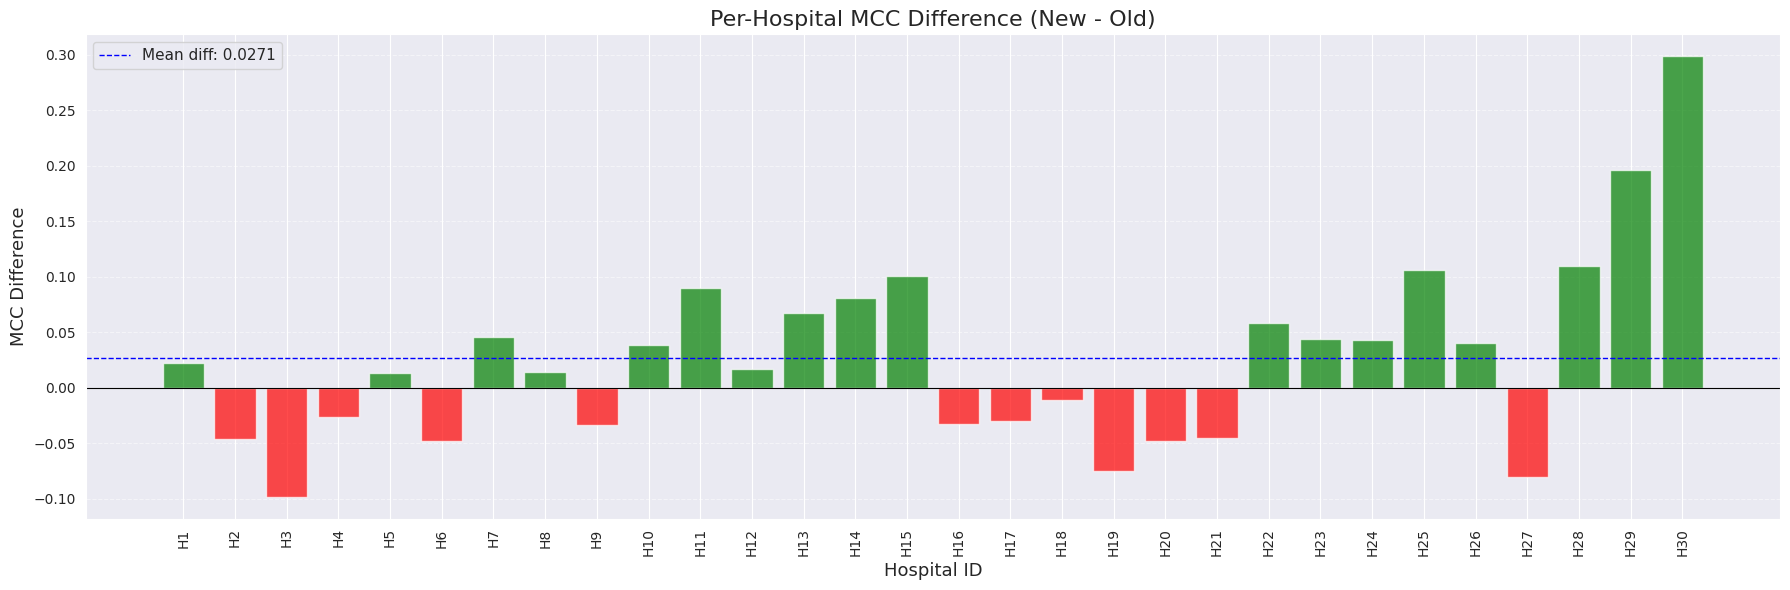

In [8]:
for metric in ['auc', 'mcc']:
    diff_vals = new_df[metric].values - old_df[metric].values

    fig, ax = plt.subplots(figsize=(18, 6))
    colors = ['green' if d > 0 else 'red' for d in diff_vals]
    ax.bar(hospitals, diff_vals, color=colors, alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axhline(np.mean(diff_vals), color='blue', linewidth=1, linestyle='--',
               label=f'Mean diff: {np.mean(diff_vals):.4f}')
    ax.set_title(f'Per-Hospital {metric.upper()} Difference (New - Old)', fontsize=16)
    ax.set_ylabel(f'{metric.upper()} Difference', fontsize=13)
    ax.set_xlabel('Hospital ID', fontsize=13)
    ax.tick_params(axis='x', rotation=90)
    ax.legend(fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    fig.tight_layout()
    fig.savefig(f'{FIGURES_DIR}/old_vs_new_{metric}_diff.png', dpi=150, bbox_inches='tight')
    plt.show()

## Boxplot — Distribution Comparison

/tmp/ipykernel_3281117/70727830.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='tag', y=metric, ax=ax,
/tmp/ipykernel_3281117/70727830.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='tag', y=metric, ax=ax,
/tmp/ipykernel_3281117/70727830.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='tag', y=metric, ax=ax,
/tmp/ipykernel_3281117/70727830.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legen

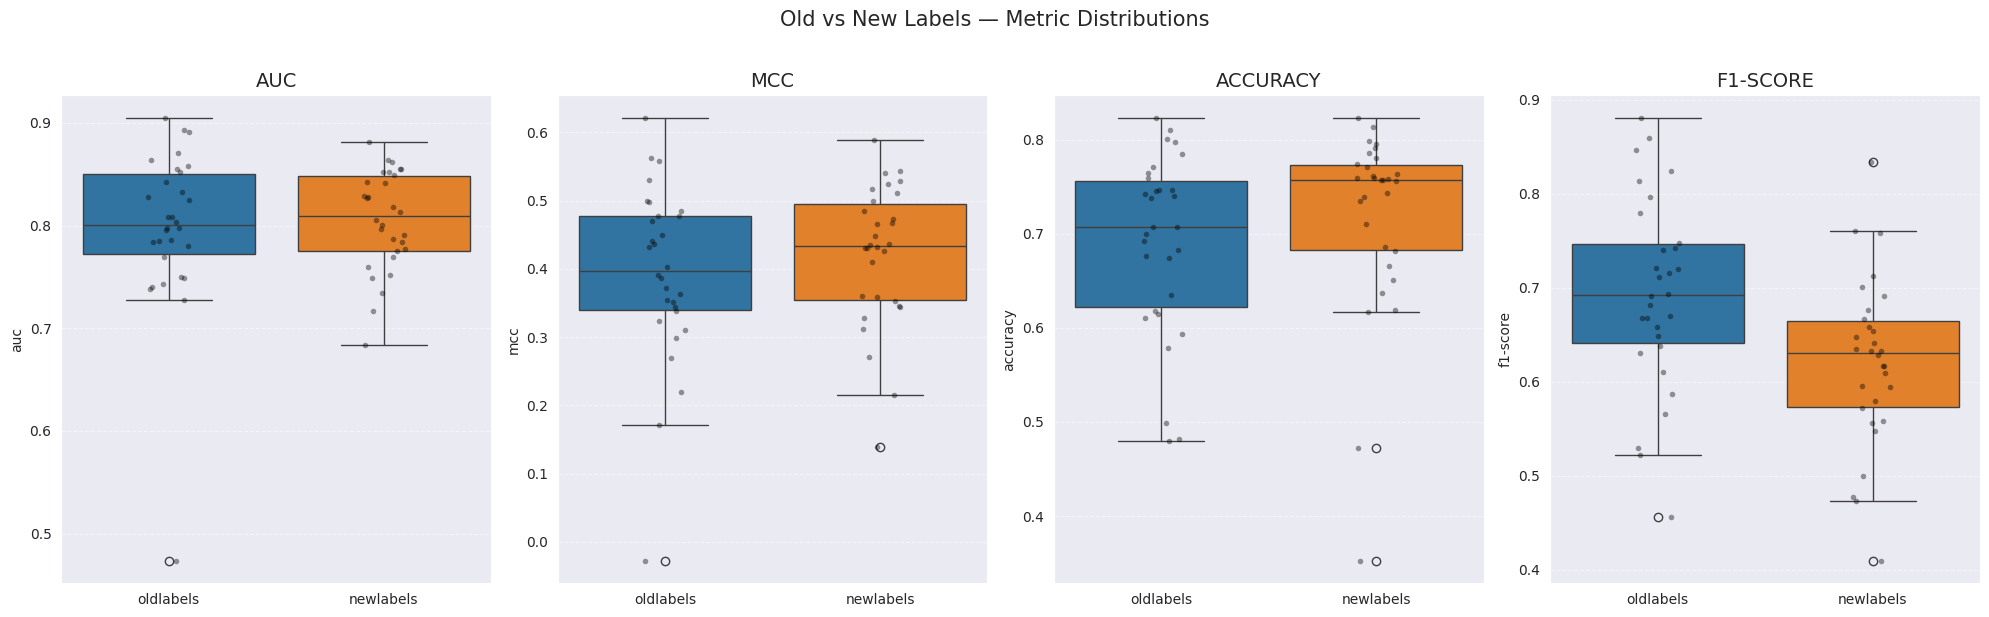

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

for ax, metric in zip(axes, ['auc', 'mcc', 'accuracy', 'f1-score']):
    sns.boxplot(data=df, x='tag', y=metric, ax=ax,
                palette=LABEL_COLORS, order=['oldlabels', 'newlabels'])
    sns.stripplot(data=df, x='tag', y=metric, ax=ax,
                  color='black', alpha=0.4, size=4, order=['oldlabels', 'newlabels'])
    ax.set_title(metric.upper(), fontsize=14)
    ax.set_xlabel('')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

fig.suptitle('Old vs New Labels — Metric Distributions', fontsize=15, y=1.02)
fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/old_vs_new_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## Scatter — Old vs New AUC per Hospital

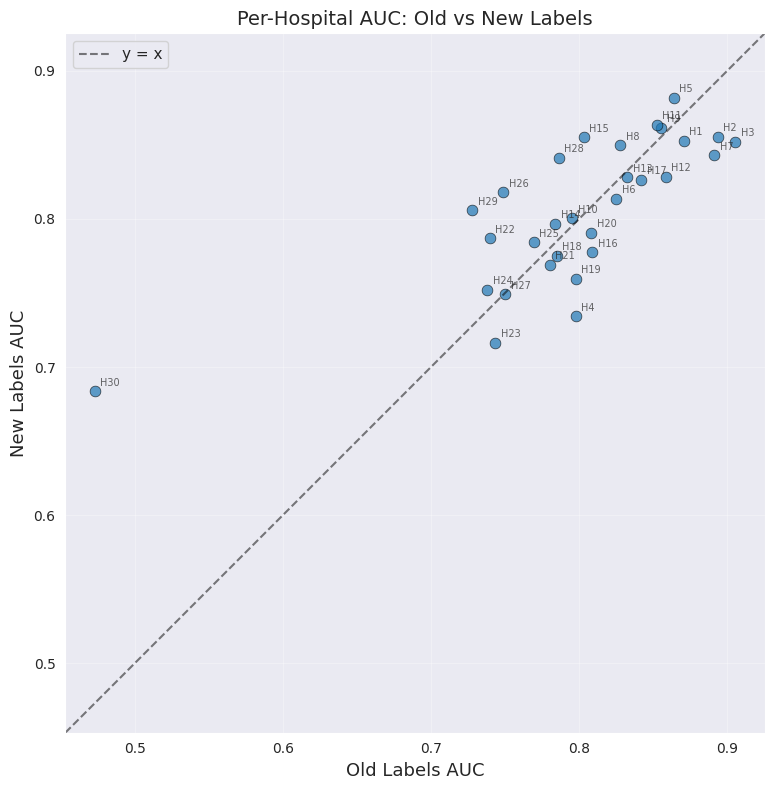

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))

old_auc = old_df['auc'].values
new_auc = new_df['auc'].values

ax.scatter(old_auc, new_auc, s=60, alpha=0.7, edgecolors='black', linewidths=0.5)
for i, h in enumerate(hospitals):
    ax.annotate(h, (old_auc[i], new_auc[i]), fontsize=7, alpha=0.7,
                xytext=(4, 4), textcoords='offset points')

lims = [min(old_auc.min(), new_auc.min()) - 0.02, max(old_auc.max(), new_auc.max()) + 0.02]
ax.plot(lims, lims, 'k--', alpha=0.5, label='y = x')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Old Labels AUC', fontsize=13)
ax.set_ylabel('New Labels AUC', fontsize=13)
ax.set_title('Per-Hospital AUC: Old vs New Labels', fontsize=14)
ax.legend(fontsize=11)
ax.set_aspect('equal')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/old_vs_new_auc_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Winners/Losers — Which Hospitals Improved?

In [11]:
comparison = pd.DataFrame({
    'hospital': hospitals,
    'old_auc': old_df['auc'].values,
    'new_auc': new_df['auc'].values,
    'old_mcc': old_df['mcc'].values,
    'new_mcc': new_df['mcc'].values,
    'n_test': old_df['n_test'].values
})
comparison['auc_diff'] = comparison['new_auc'] - comparison['old_auc']
comparison['mcc_diff'] = comparison['new_mcc'] - comparison['old_mcc']
comparison['auc_improved'] = comparison['auc_diff'] > 0

print(f"Hospitals with improved AUC: {comparison['auc_improved'].sum()} / {len(comparison)}")
print(f"Hospitals with improved MCC: {(comparison['mcc_diff'] > 0).sum()} / {len(comparison)}")
print()
print(comparison.sort_values('auc_diff', ascending=False).to_string(index=False))

Hospitals with improved AUC: 14 / 30
Hospitals with improved MCC: 18 / 30

hospital  old_auc  new_auc   old_mcc  new_mcc  n_test  auc_diff  mcc_diff  auc_improved
     H30 0.473227 0.683697 -0.028133 0.270442    1225  0.210470  0.298574          True
     H29 0.728002 0.805695  0.269786 0.466087     990  0.077693  0.196301          True
     H26 0.748655 0.817939  0.391232 0.431947    1564  0.069285  0.040715          True
     H28 0.786160 0.841177  0.362850 0.472593     573  0.055017  0.109743          True
     H15 0.803108 0.855025  0.440623 0.540937    3063  0.051917  0.100314          True
     H22 0.739796 0.786939  0.352113 0.410233    3102  0.047143  0.058120          True
      H8 0.827588 0.849719  0.470365 0.484321    1650  0.022131  0.013956          True
      H5 0.863780 0.881660  0.530392 0.544020     426  0.017880  0.013628          True
     H25 0.769493 0.784278  0.323671 0.429912    4558  0.014785  0.106241          True
     H24 0.737956 0.752015  0.310016 0.353409

## Conclusions

*(Fill in after running)*